# Introduction to Regression with Neural Networks in TensorFlow

There are many definitions for a regression problem but in our case, we're going to simplfy it: predicting a numerical variable based on some other combination of variables, even shorter... predicting a number.


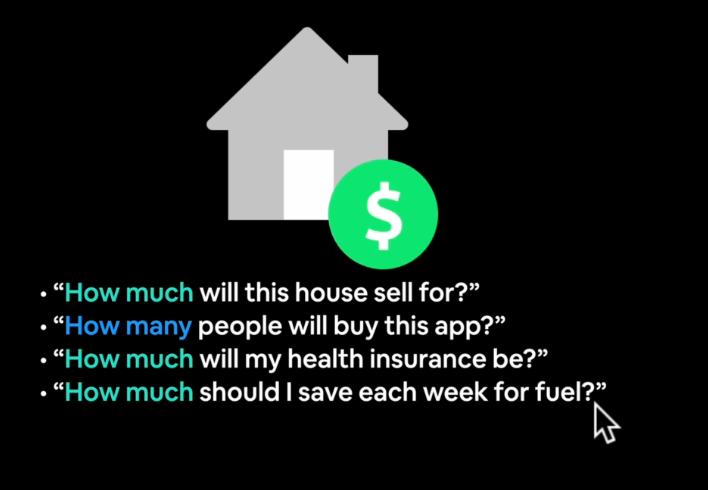

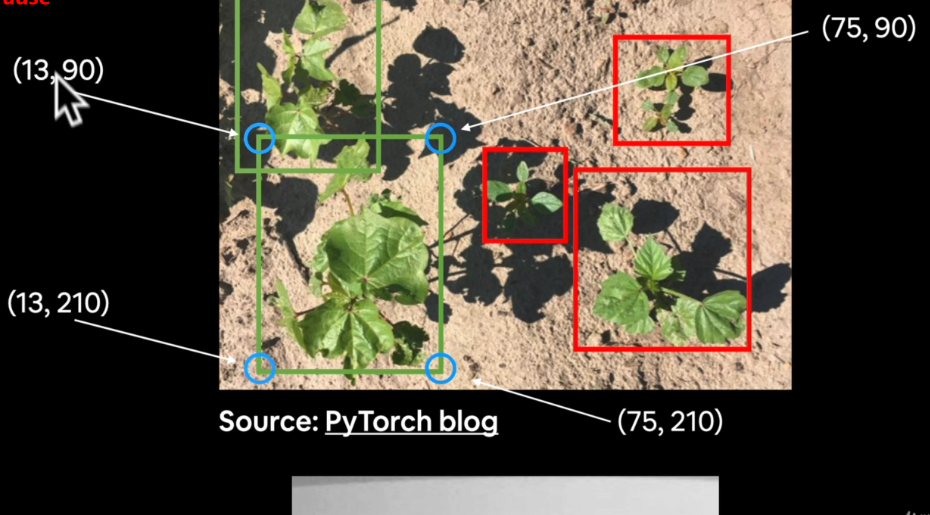

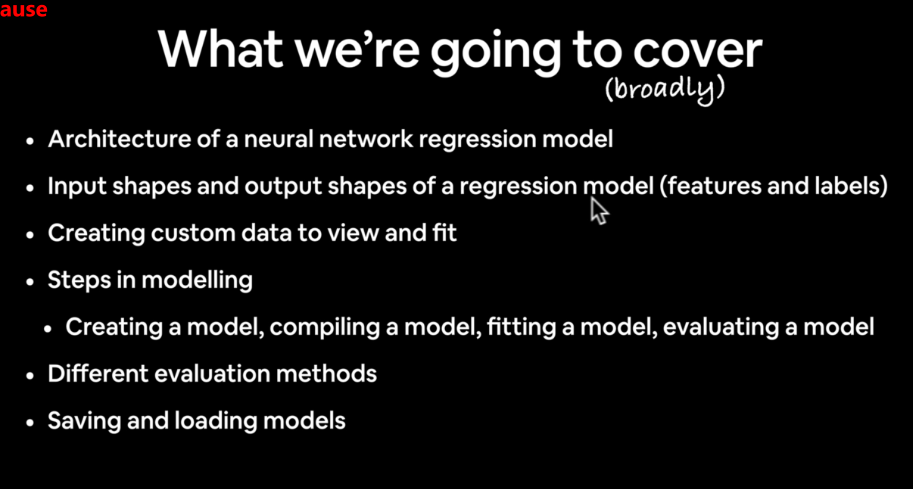

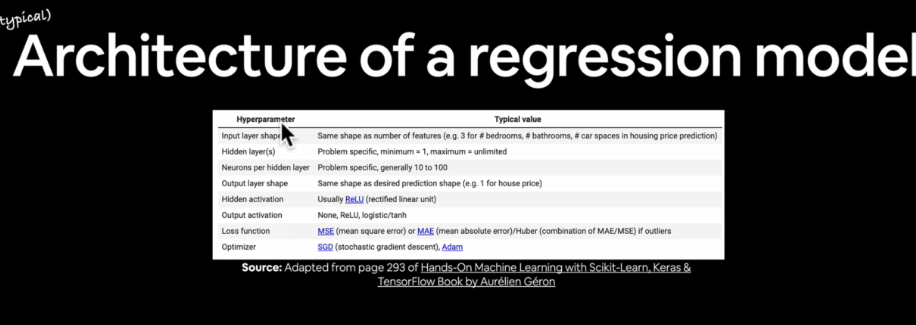

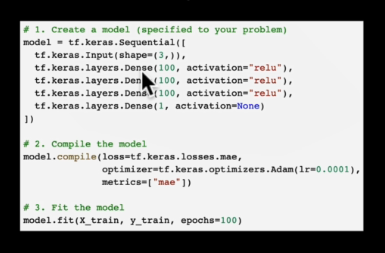

In [1]:
# Import TensorFlow
import tensorflow as tf
print(tf.__version__)

2.19.0


### Creating data to view and fit

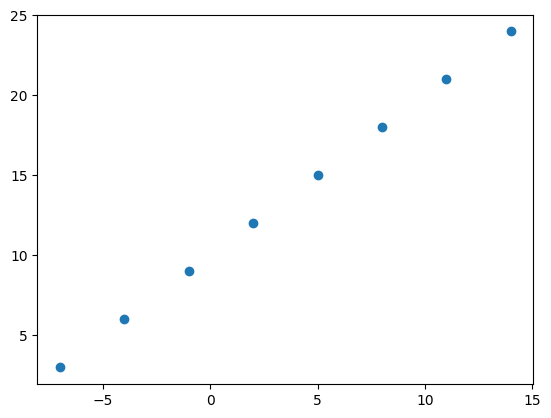

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Create features
X = np.array([-7.0,-4.0,-1.0,2.0,5.0,8.0,11.0,14.0])

# Create labels
y = np.array([3.0,6.,9.,12.,15.,18.,21.,24.])

# Visualize it
plt.scatter(X,y)

In [3]:
y == X+10

array([ True,  True,  True,  True,  True,  True,  True,  True])

### Input and output shapes

In [4]:
# Create a demo tensor for our housing price prediction problem
house_info = tf.constant(['bedroom','bathroom','garage'])
house_price = tf.constant([939700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [5]:
input_shape = X.shape
output_shape = y.shape
input_shape, output_shape

((8,), (8,))

In [6]:
X[0],y[0] # we're going to predict one y value with one x value

(np.float64(-7.0), np.float64(3.0))

In [7]:
X[0].ndim # 0 because it is scalar

0

<h1 style="color:red">lec 005:-The major steps in modelling with TensorFlow</h1>

In [8]:
# Turn our Numpy arrays into tensors
X= tf.cast(tf.constant(X),dtype=tf.float32)
y = tf.cast(tf.constant(y),dtype=tf.float32)
X,y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [9]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape,output_shape

(TensorShape([]), TensorShape([]))

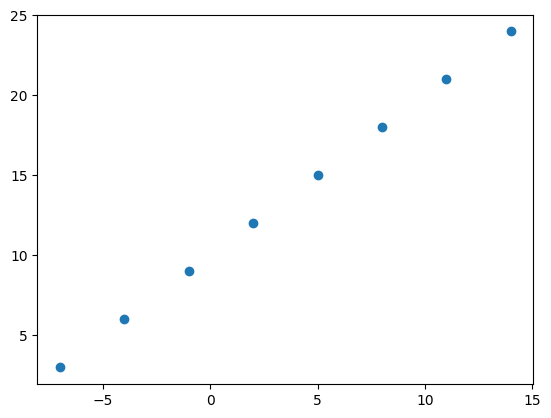

In [10]:
plt.scatter(X,y)

## Steps in modelling with TensorFlow

1. **Creating a model** - define the input and output layers, as well as the hidden layers of a deep learning model.
2. **Compiling a model** - define the loss function (in other words, the function which tells our model how wrong it is) and the optimizer (tells our model how to improve the pattern its learning) and evaluation metrics (what we can use to interpret the performance of our model).
3. **Fitting a model** - letting the model try to find patterns between X & y (features and labels).

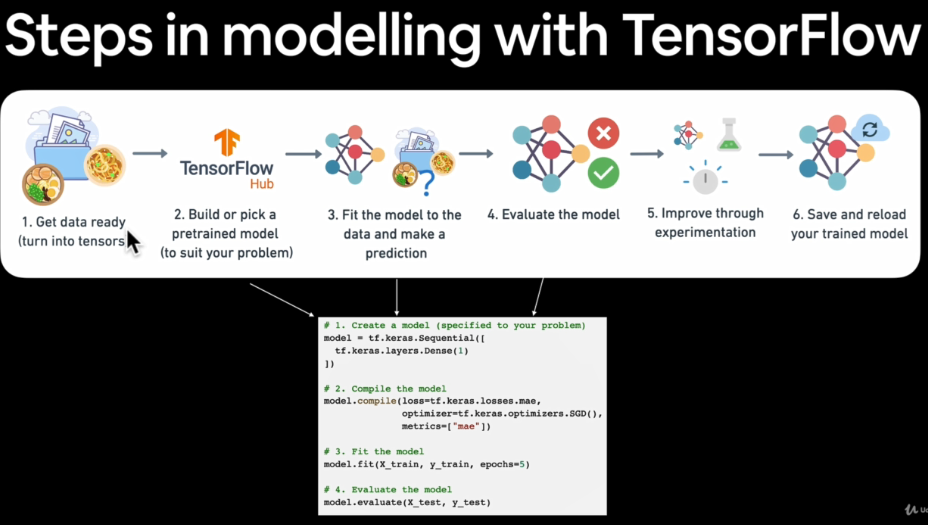

In [11]:
# # Optionally, the first layer can receive an `input_shape` argument:
# model = tf.keras.Sequential()
# model.add(tf.keras.layers.Dense(8,input_shape=(16,)))
# # Afterwards, we do automatic shape inference:
# model.add(tf.keras.layers.Dense(4))


# model = tf.kears.sequential()    # same as we are doing below
# model.add(tf.keras.layers.Dense(1))
# model.add(tf.keras.layers.Dense(1))

In [12]:
# Set random seed
tf.random.set_seed(42)

# 1. create a model using sequential api
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1), # here 1 is number of neurons
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss= tf.keras.losses.MAE, # mae is short for mean absolute error
              optimizer = tf.keras.optimizers.SGD(), # SGD is short for stochastic gradient descent
              metrics = ["mae"]) # we can also use "sgd" instead of tf.keras.optimizers.SGD()

# 3. Fit the model
X = tf.reshape(X,shape =(-1,1)) # because dense layer expect 2D tensor
model.fit(X,y,epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 7.5000 - mae: 7.5000
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 7.4776 - mae: 7.4776
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 7.4552 - mae: 7.4552
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - loss: 7.4328 - mae: 7.4328
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 7.4104 - mae: 7.4104


One-line mental rule

Dense layers never accept rank-1 tensors.

Reshape once. Error gone.

In [13]:
# Check out X and y
X,y


(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [14]:
# Try and make a prediction using our model
y_pred = model.predict(np.array([[17.0]], dtype=np.float32)) # don't give direct list first convert them into numpy arrays or tensors
y_pred
# Expected answer = 27.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


array([[31.53512]], dtype=float32)

In [15]:
y_pred - 7.4 # (mae of this epoch is 7.4)


array([[24.13512]], dtype=float32)

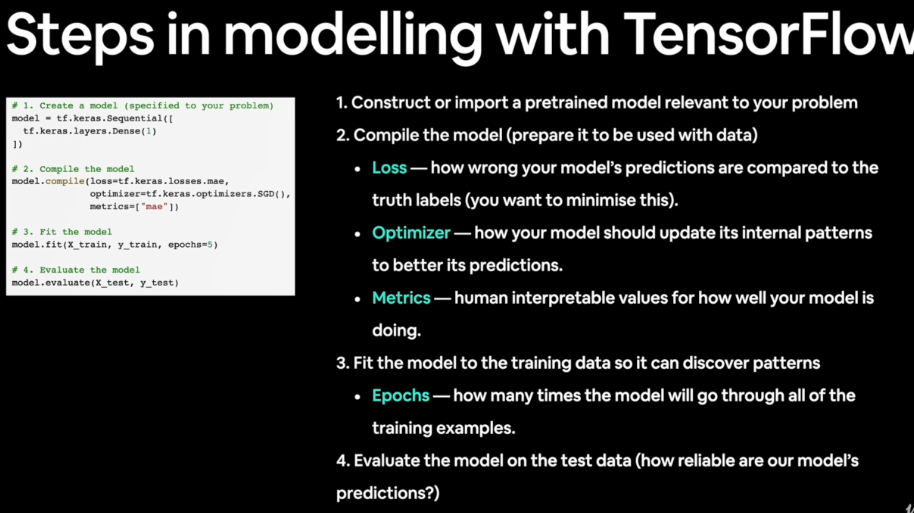

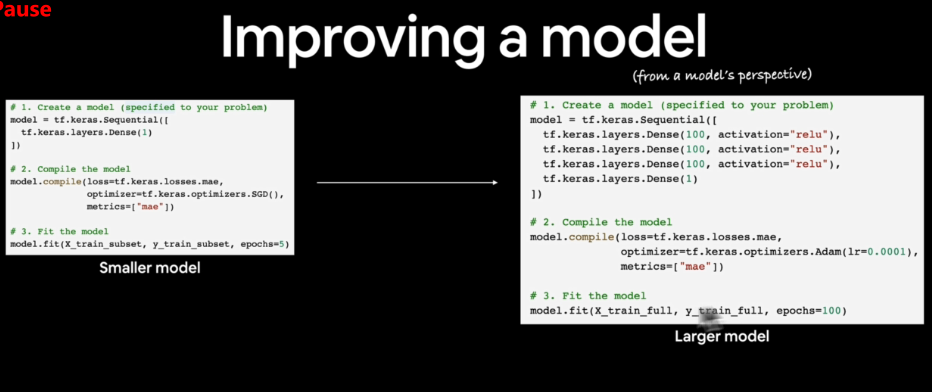

<h1 style="color:red">lec 006:-Steps in improving a model with TensorFlow part 1.mp4</h1>

### Improve our model

We can improve our model, by altering the steps we took to create a model.

1. **Creating a model** - here we might add more layers, increase the number of hidden units (all called neurons) within each of hidden layers, change the activation function of each layer.

2. **Compiling a model** - here we might change the optimization function or perhaps the **learning rate** of the optimization function.

3. **Fitting a model** - here we might fit a model for more **epochs** (leave it training for longer) or on more data (give the model more examples to learn from).

<h1 style="color:red">lec 007:-Steps in improving a model with TensorFlow part 2.mp4</h1>

In [16]:
# Let's rebuild our model

# 1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["mae"]
)

# 3. Fit the model (this time we'll train for longer)
model.fit(X,y,epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 869ms/step - loss: 18.1448 - mae: 18.1448
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 18.1388 - mae: 18.1388
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - loss: 18.1328 - mae: 18.1328
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - loss: 18.1268 - mae: 18.1268
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 18.1208 - mae: 18.1208
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 18.1148 - mae: 18.1148
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 18.1088 - mae: 18.1088
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 18.1028 - mae: 18.1028
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 18.0968 - mae: 18.0968
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 18.0908 - mae: 18.0908
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 18.0848 - mae: 18.0848
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 18.0788 - mae: 18.0788
Epoch 13/100
1/1 ━

In [17]:
# Remind ourselves of the data
X,y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [18]:
# Let's see if our model's prediction has improved...
model.predict(np.array([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


array([[-15.668969]], dtype=float32)

<h1 style="color:red">lec 008:-Steps in improving our model with TensorFlow part 3</h1>

In [19]:
# Let's see if we can make another change to improve our model

# 1. Create the model (this time with an extra hidden layer with 100 hidden units)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100,activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(
    loss = "mae",
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics = ["mae"]
)

# 3. Fit the model
model.fit(X,y,epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 13.9324 - mae: 13.9324
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 13.1110 - mae: 13.1110
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 12.2968 - mae: 12.2968
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 11.5064 - mae: 11.5064
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 10.8046 - mae: 10.8046
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 10.2213 - mae: 10.2213
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 9.6214 - mae: 9.6214
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 9.0098 - mae: 9.0098
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 8.3907 - mae: 8.3907
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 7.7526 - mae: 7.7526
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 7.0865 - mae: 7.0865
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 6.3914 - mae: 6.3914
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━

In [20]:
# Let's remind ourselves of the data
X,y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [21]:
model.predict(np.array([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


array([[27.047188]], dtype=float32)

**Note:** - learning_rate is most important hyperparameter for neural networks

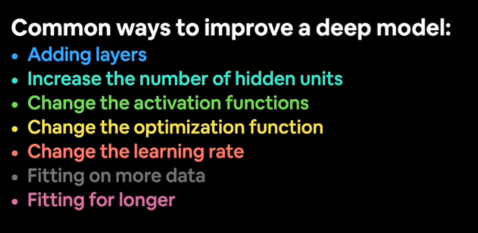

<h1 style="color:red">lec 009:-Evaluating a TensorFlow model part 1 (_visualise, visualise, visualise_).mp4</h1>

## Evaluating a model

In practice, a typical workflow you'll go through when building neural network is:

```
Build a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it...

When it comes to evaluation.. there are 3 words you should memorize:

> "visualize, visualize, visualize"

It's a good idea to visualize:
* The data - what data are we working with? what does it look like?
* The model itself - what does our model look like?
* The training of a model - how does a model perform while it learns?
* The predictions of the model - how do the predictions of a model line up against the ground truth (the original labels)?

In [22]:
# Make  a bigger dataset
X = tf.cast(tf.range(-100,100,4),dtype=tf.float32)
y = X+10
X = tf.reshape(X,shape =(-1,1))
print(X,y)

tf.Tensor(
[[-100.]
 [ -96.]
 [ -92.]
 [ -88.]
 [ -84.]
 [ -80.]
 [ -76.]
 [ -72.]
 [ -68.]
 [ -64.]
 [ -60.]
 [ -56.]
 [ -52.]
 [ -48.]
 [ -44.]
 [ -40.]
 [ -36.]
 [ -32.]
 [ -28.]
 [ -24.]
 [ -20.]
 [ -16.]
 [ -12.]
 [  -8.]
 [  -4.]
 [   0.]
 [   4.]
 [   8.]
 [  12.]
 [  16.]
 [  20.]
 [  24.]
 [  28.]
 [  32.]
 [  36.]
 [  40.]
 [  44.]
 [  48.]
 [  52.]
 [  56.]
 [  60.]
 [  64.]
 [  68.]
 [  72.]
 [  76.]
 [  80.]
 [  84.]
 [  88.]
 [  92.]
 [  96.]], shape=(50, 1), dtype=float32) tf.Tensor(
[-90. -86. -82. -78. -74. -70. -66. -62. -58. -54. -50. -46. -42. -38.
 -34. -30. -26. -22. -18. -14. -10.  -6.  -2.   2.   6.  10.  14.  18.
  22.  26.  30.  34.  38.  42.  46.  50.  54.  58.  62.  66.  70.  74.
  78.  82.  86.  90.  94.  98. 102. 106.], shape=(50,), dtype=float32)


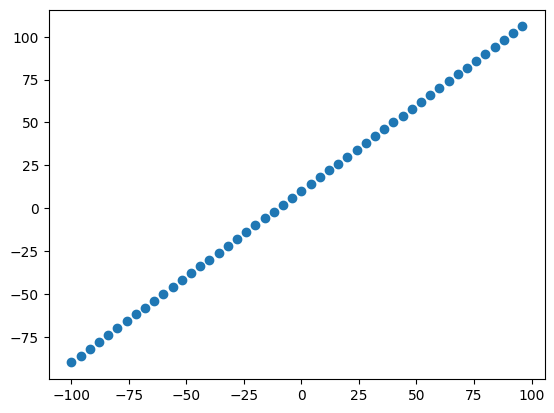

In [23]:
# Visualize the data
import matplotlib.pyplot as plt

plt.scatter(X,y)

<h1 style="color:red">lec 010:-Evaluating a TensorFlow model part 2 (the three datasets).mp4</h1>

### The 3 sets...

* Training set - the model learns from this data, which is typically 70-80% of the data you have available.
* Validation set - the model gets tuned on this data, which is typically 10-15% of the data available.
* Test set - the model gets evaluated on this data to test what it has learned, this set is typically 10-15% of the total data available.

In [24]:
# Check the length of how many samples we have
len(X)

50

In [25]:
# Split the data into train and test sets
X_train = X[:40] # first 40 are training samples (80% of the data)
y_train = y[:40]

X_test = X[40:] # last 10 are testing samples (20% of the data)
y_test = y[40:]

### Visualizing the data

Now we've got our data in training and test sets... let's visualize it again!

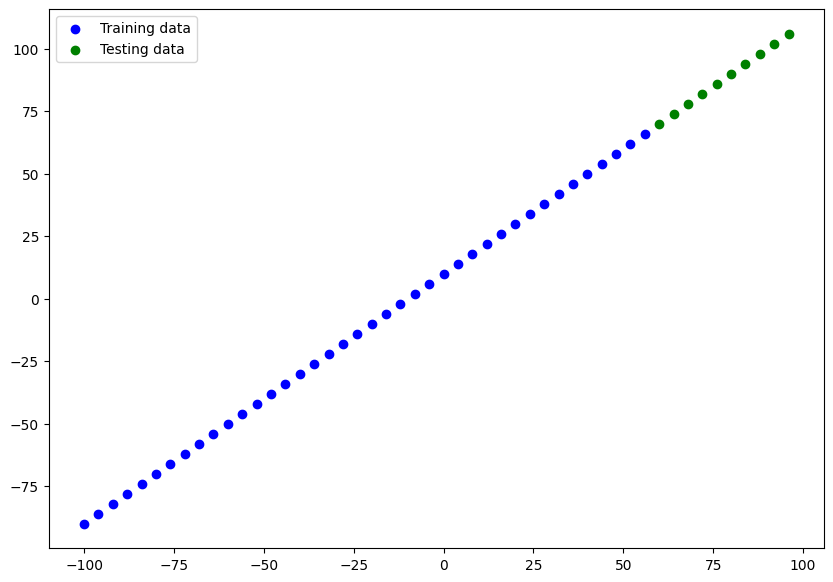

In [26]:
plt.figure(figsize=(10,7))
# Plot training data in blue
plt.scatter(X_train, y_train, c="b", label="Training data")
# Plot test data in green
plt.scatter(X_test,y_test,c="g",label = "Testing data")
# Show a legend
plt.legend()

<h1 style="color:red">lec 011:- Evaluating a TensorFlow model part 3 (getting a model summary).mp4</h1>

In [27]:
# Let's have a look at how to build a neural network for our data

# 1. Create a model
# model = tf.keras.Sequential([
#     tf.keras.layers.Dense(1)
# ])

# # 2. Compile the model
# model.compile(
#     loss = tf.keras.losses.mae,
#     optimizer = tf.keras.optimizers.SGD(),
#     metrics = ["mae"]
# )

# 3. Fit the model
# model.fit(X_train,y_train,epochs=100)

# Visualizing the model

In [28]:
# model.summary()

In [29]:
X[0].shape

TensorShape([1])

In [30]:
# Let's create a model which builds automatically by defining the input_shape argument
tf.random.set_seed(42)

# Create a model (same as above)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1,input_shape=[1],name = "input_layer")
], name ="model_1")

# 2. Compile the model
model.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics = ["mae"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

* Total params - total number of parameters in the model.
* Trainable parameters - these are the parameters (patterns) the model can update as it trains
* Non-trainable params - these parameters aren't updated during training (this is typical when you bring in already learn patterns or parameters from other models during **transfer learning**).

**Resource:** For a more in-depth overview of the trainable parameters wuth a layer, check out MIT's introduction to deep learning video.

**Exercise:** Try playing around with the number of hidden units in the dense layer, see how that effects the number of parameters (total and trainable) by calling `model.summary()`.

In [32]:
# Let's fit our model to training data
model.fit(X_train,y_train,epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7.6003 - mae: 7.6003 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 8.6131 - mae: 8.6131
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 10.0819 - mae: 10.0819
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 11.7939 - mae: 11.7939
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 8.7229 - mae: 8.7229
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 10.1916 - mae: 10.1916
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 11.9410 - mae: 11.9410
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 12.7584 - mae: 12.7584
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 8.2045 - mae: 8.2045
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 8.8835 - mae: 8.8835
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 7.9177 - mae: 7.9177
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 9.5684 - mae: 9.5684
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 

In [33]:
# Get a summary of our model
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

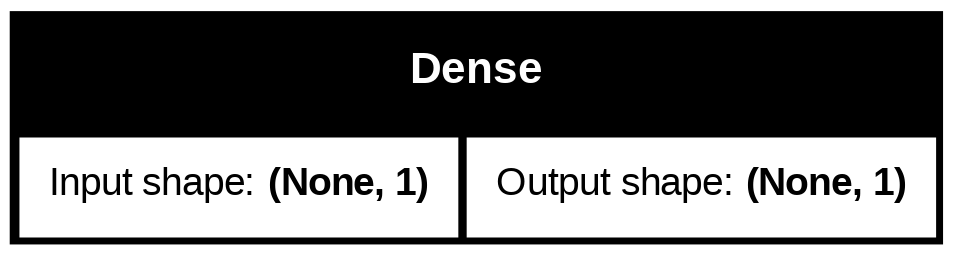

In [34]:
from tensorflow.keras.utils import plot_model

plot_model(model = model,show_shapes = True)

<h1 style="color:red">lec 013:- Evaluating a TensorFlow model part 5 (visualising a model's predictions).mp4</h1>

### Visualizing our model's predictions

To visualize predictions it's a good idea to plot them against the ground truth labels.

Often you'll see this in the form of `y_test` or `y_true` versus `y_pred` (ground truth versus your model's predictions).

In [35]:
# Make some predictions
y_pred  = model.predict(X_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


array([[57.30656],
       [61.03204],
       [64.75752],
       [68.483  ],
       [72.20848],
       [75.93396],
       [79.65944],
       [83.38492],
       [87.1104 ],
       [90.83588]], dtype=float32)

In [36]:
y_test,X_test

(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([ 70.,  74.,  78.,  82.,  86.,  90.,  94.,  98., 102., 106.],
       dtype=float32)>,
 <tf.Tensor: shape=(10, 1), dtype=float32, numpy=
 array([[60.],
        [64.],
        [68.],
        [72.],
        [76.],
        [80.],
        [84.],
        [88.],
        [92.],
        [96.]], dtype=float32)>)

**Note:** If  you feel like you're going to reuse some kind of functionality in the future, it's a good idea to turn it into a function.

In [37]:
# Let's create a plotting function
def plot_predictions(train_data=X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions=y_pred):
  """
  Plots training data, test data  and compares predictions to ground truth labels
  """
  plt.figure(figsize=(10,7))
  # Plot training data in blue
  plt.scatter(train_data,train_labels,c="b",label="Training data")
  # Plot testing data in green
  plt.scatter(test_data,test_labels,c="g",label="Testing data")
  # Plot the predictions in red
  plt.scatter(test_data,predictions,c="r",label = "Predictons")
  # Show the legend
  plt.legend();

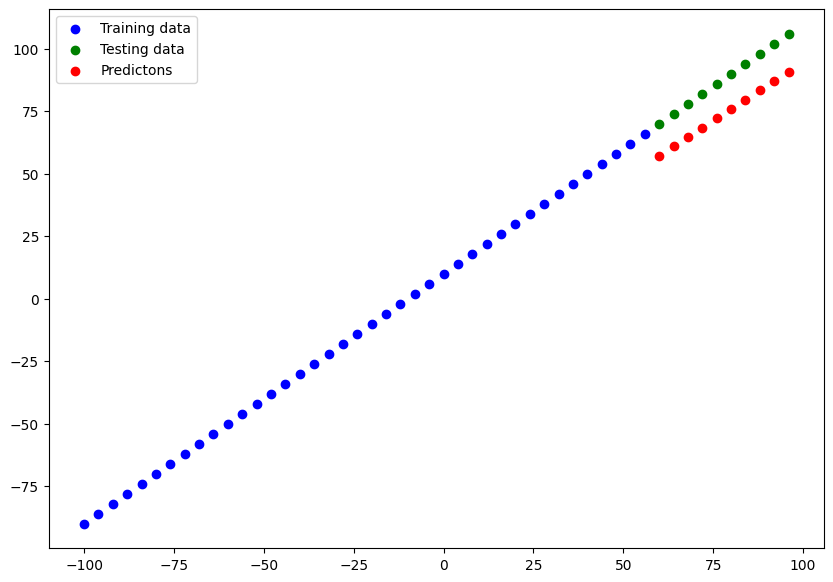

In [38]:
plot_predictions()

<h1 style="color:red">lec 014:-Evaluating a TensorFlow model part 6 (common regression evaluation metrics).mp4</h1>

### Evaluating our model's predictions with regression evaluation metrics

Depending on the problem you're working in, there will be different evaluations metrics to evaluate your model's performance.

Since we're working on a regression, two of the main metrics:
* MAE
* MSE

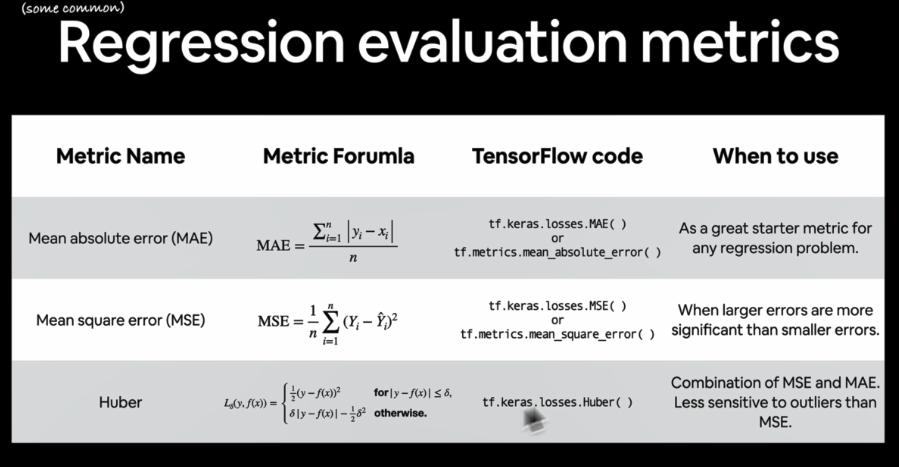

In [39]:
# Evaluate the model on test set
model.evaluate(X_test,y_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 13.9288 - mae: 13.9288


[13.928781509399414, 13.928781509399414]

In [40]:
# Calculate the mean absolute error
mae = tf.keras.losses.mae(y_pred=y_pred,y_true=y_test)
mae

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([12.6934395, 12.96796  , 13.242477 , 13.516998 , 13.791519 ,
       14.06604  , 14.340561 , 14.615082 , 14.889603 , 15.164124 ],
      dtype=float32)>

In [41]:
y_pred

array([[57.30656],
       [61.03204],
       [64.75752],
       [68.483  ],
       [72.20848],
       [75.93396],
       [79.65944],
       [83.38492],
       [87.1104 ],
       [90.83588]], dtype=float32)

In [42]:
y_test

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 70.,  74.,  78.,  82.,  86.,  90.,  94.,  98., 102., 106.],
      dtype=float32)>

In [43]:
# y_test , y_pred must have same dimensions
y_pred = tf.squeeze(y_pred)
# Calculate the mean absolute error
mae = tf.keras.losses.mae(y_pred=y_pred,y_true=y_test)
mae

<tf.Tensor: shape=(), dtype=float32, numpy=13.928781509399414>

In [44]:
# Calculate the mean square error
mse = tf.keras.losses.mse(y_pred=y_pred,y_true=y_test)
mse

<tf.Tensor: shape=(), dtype=float32, numpy=194.63265991210938>

In [45]:
# Make some function to reuse MAE and MSE
def mae(y_true,y_pred):
  return tf.keras.losses.mae(y_pred=tf.squeeze(y_pred),y_true=y_true)

def mse(y_true,y_pred):
  return tf.keras.losses.mse(y_pred=tf.squeeze(y_pred),y_true=y_true)

<h1 style="color:red">lec 017:-Setting up TensorFlow modelling experiments part 1 (start with a simple model).mp4</h1>

### Running experiments to improve our model

```
Build a model -> fit it -> evaluate it -> tweak it -> fit it -> evaluate it...
```

1. Get more data - get more examples for your model to train on (more opportunities to learn pattern or relationships between features and labels).
2. Make your model larger (using a more complex model) - this might come in the form of more layers or more hidden units in each layer.
3. Train for longer - give your model more of a chance to find patterns in the data.

Let's do 3 modelling experiments:

1. `model_1` - same as the original model, 1 layer, trained for 100 epochs.
2. `model_2` - 2 layers, trained for 100 epochs
3. `model_3` - 2 layers, trained for 500 epochs

**Build `model_1`**

In [46]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_1.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.SGD(),
    metrics = ["mae"]
)

# 3. Fit the model
model_1.fit(X_train,y_train,epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 88.9723 - mae: 88.9723 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 53.8041 - mae: 53.8041
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 19.8341 - mae: 19.8341
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 8.7368 - mae: 8.7368
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 10.2055 - mae: 10.2055
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 11.9477 - mae: 11.9477
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 8.8465 - mae: 8.8465
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 10.3153 - mae: 10.3153
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 12.1204 - mae: 12.1204
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 12.5292 - mae: 12.5292
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 7.9924 - mae: 7.9924
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 9.6961 - mae: 9.6961
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


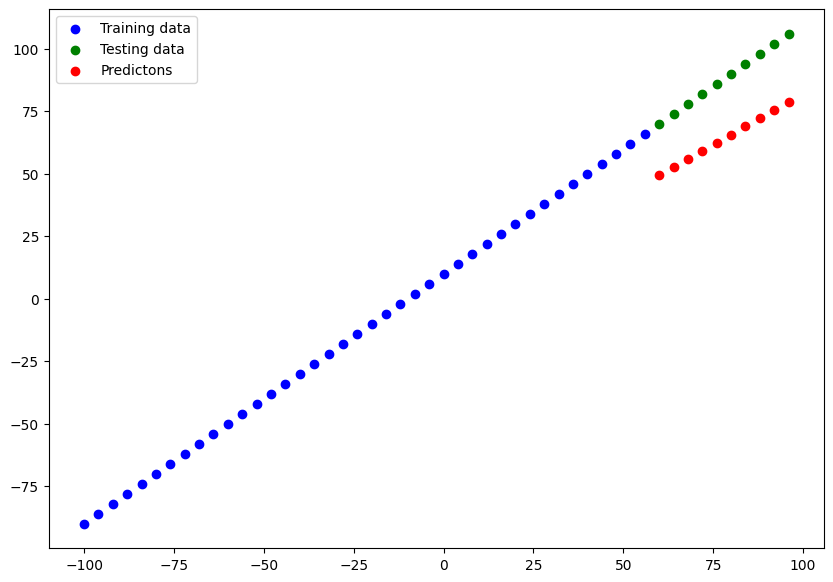

In [47]:
# Make and plot predictions for model_1
y_preds_1 = model_1.predict(X_test)
plot_predictions(predictions=y_preds_1)

In [48]:
# Calculate model_1 evaluation metrics
mae_1 = mae(y_test,tf.squeeze(y_preds_1)) # squeeze because dimension should be equal y_preds_1 dimension are (10,1) we have to make it (10,) so we squeezed it
mse_1 = mse(y_test,y_preds_1) # we don't need to squeeze now because we made the change in function above
mae_1,mse_1

(<tf.Tensor: shape=(), dtype=float32, numpy=23.912395477294922>,
 <tf.Tensor: shape=(), dtype=float32, numpy=576.8772583007812>)

<h1 style="color:red">lec 018:-Setting up TensorFlow modelling experiments part 2 (increasing complexity).mp4</h1>

**Build `model_2`**

* 2 dense layers, trained for 100 epochs (we didn't specify hidden units in first layer hidden units means no. of neurons in that layer)

In [49]:
# Set the random seed
tf.random.set_seed(42)

# 1. create model_2
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_2.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.SGD(),
    metrics = ["mse"]
)

# 3. Fit the model
model_2.fit(X_train,y_train,epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 26.2040 - mse: 1099.5010
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 22.8816 - mse: 760.4054 
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 21.8433 - mse: 650.4081
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 22.3708 - mse: 675.6243
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 14.8602 - mse: 321.7853 
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 15.5483 - mse: 337.4938 
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 15.8684 - mse: 343.5879
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 11.3455 - mse: 201.3291
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 15.1772 - mse: 316.5222
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 11.0757 - mse: 194.3485
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 14.9021 - mse: 306.0721
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 10.9677 - mse: 191.3822
Epoch 13/

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


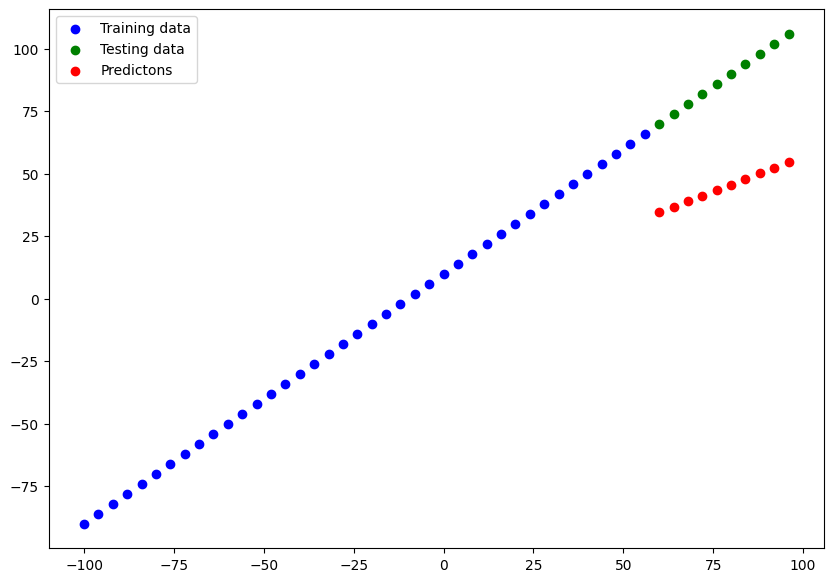

In [50]:
# Make and plot predictions for model_2
y_preds_2 = model_2.predict(X_test)
plot_predictions(predictions = y_preds_2)

In [51]:
# Calculate model_2 evaluation metrics
mae_2 = mae(y_test,y_preds_2)
mse_2 = mse(y_test,y_preds_2)
mae_2,mse_2

(<tf.Tensor: shape=(), dtype=float32, numpy=43.400856018066406>,
 <tf.Tensor: shape=(), dtype=float32, numpy=1910.1624755859375>)

**Build `model_3`**

* 2 layers, trained for 500 epochs

In [52]:
# Set the random seed
tf.random.set_seed(42)

# 1. create model_2
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.SGD(),
    metrics = ["mae"]
)

# 3. Fit the model
model_3.fit(X_train,y_train,epochs=500)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 36.0656 - mae: 36.0656 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 24.9249 - mae: 24.9249
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 19.5614 - mae: 19.5614
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 17.2823 - mae: 17.2823
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 16.1774 - mae: 16.1774
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 16.3914 - mae: 16.3914
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 11.9512 - mae: 11.9512
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 14.8604 - mae: 14.8604
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 15.7675 - mae: 15.7675 
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 11.8983 - mae: 11.8983
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 14.8996 - mae: 14.8996
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 11.0039 - mae: 11.0039
Epoch 13/500
2/2 ━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


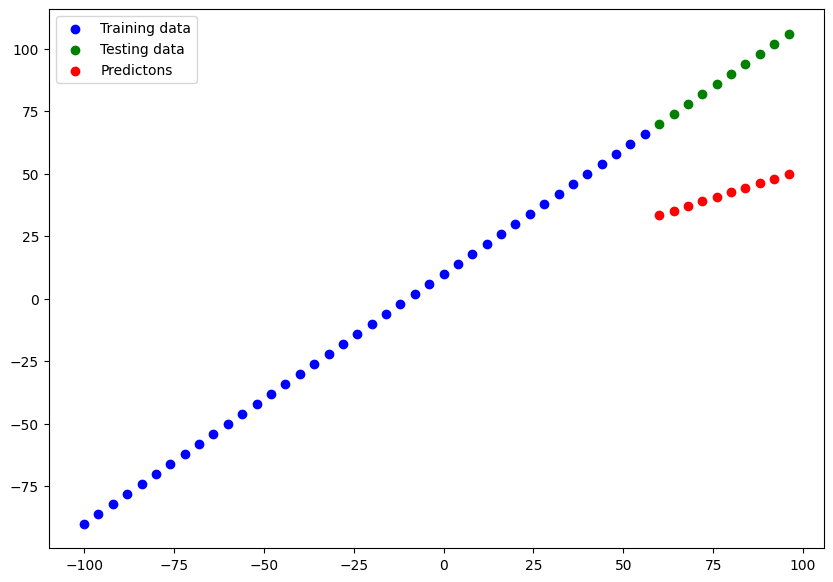

In [53]:
# Make and plot some predictions
y_preds_3 = model_3.predict(X_test)
plot_predictions(predictions=y_preds_3)

In [54]:
# Calculate model_3 evaluation metrics
mae_3 = mae(y_test,y_preds_3)
mse_3 = mse(y_test,y_preds_3)
mae_3, mse_3

(<tf.Tensor: shape=(), dtype=float32, numpy=46.32030487060547>,
 <tf.Tensor: shape=(), dtype=float32, numpy=2184.34130859375>)

**Note:** You want to start with small experiments (small models) and make sure they work and then increase their scale when necessary.

<h1 style="color:red">lec 019:-Comparing and tracking your TensorFlow modelling experiments.mp4</h1>

## Comparing the results of our experiments

We've run a few experiments, let's compare the results

In [55]:
# Let's compare our model's results using a pandas DataFrame
import pandas as pd

model_results = [["model_1",mae_1.numpy(),mse_1.numpy()],
                 ["model_2",mae_2.numpy(),mse_2.numpy()],
                 ["model_3",mae_3.numpy(),mse_3.numpy()]]

all_model_results = pd.DataFrame(model_results,columns = ["model","mae","mse"])
# all_model_results["mae"].apply(lambda x:x.numpy()) # can't do this because we have to do it when they are raw
# all_model_results["mse"].apply(lambda x:x.numpy())
"""
Only metric tensors (from Keras computations) have .numpy().

If you stored the class/function, it will throw the AttributeError.
"""
all_model_results

,model,mae,mse
0,model_1,23.912395,576.877258
1,model_2,43.400856,1910.162476
2,model_3,46.320305,2184.341309


# Looks like `model_1` performed the best...

In [56]:
model_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

> **Note:** One of your main goals should be to minimize the time between your experiments. The more experiments you do, the more things you'll figure out which don't work and in turn, get closer to figuring out what does work. Remember the machine learning practitioner's motto: "experiment, experiment, experiment".

## Tracking your experiments

One really good habit in machine learning modelling is to track the results of your experiments.

And when doing so, it can be tedious if you're running lots of experiments.

Luckily, there are tools to help us!

**Resource:** As you build more models, you'll want to look into using:

* TensorBoard - a component of the TensorFlow library to help track modelling experiments (we'll see this one later).
* Weights & Biases - a tool for tracking all kinds of machine learning experiments (plugs straight into TensorBoard).

<h1 style="color:red">lec 020:-How to save a TensorFlow model.mp4</h1>

## Saving our models

Saving our models allows us to use them outside of Google Colab (or wherever they were trained) such as in a web application or a mobile app.

Below is a **clean, documentation-ready summary** with the **Keras 3 rules clearly reflected**.

---

## **Model Saving Formats in Keras 3 – Summary Table**

| Feature / Format                             | `.keras` (Keras Native)                | `.h5` (HDF5 – Legacy)    | `SavedModel` (TensorFlow)                   |
| -------------------------------------------- | -------------------------------------- | ------------------------ | ------------------------------------------- |
| **File type**                                | Single file                            | Single file              | Directory (multiple files)                  |
| **Extension**                                | `.keras`                               | `.h5`                    | No extension (folder)                       |
| **Save method**                              | `model.save("model.keras")`            | `model.save("model.h5")` | `model.export("model_dir")`                 |
| **Load method**                              | `load_model("model.keras")`            | `load_model("model.h5")` | ❌ `load_model()` not supported              |
| **Trainable after loading**                  | ✅ Yes                                  | ✅ Yes                    | ❌ No                                        |
| **Inference supported**                      | ✅ Yes                                  | ✅ Yes                    | ✅ Yes                                       |
| **Optimizer state saved**                    | ✅ Yes                                  | ✅ Yes                    | ❌ No (graph only)                           |
| **Custom layers support**                    | ✅ Yes                                  | ⚠️ Limited               | ✅ Yes                                       |
| **Recommended by Keras 3**                   | ✅ **YES (Default)**                    | ⚠️ Legacy only           | ❌ For training                              |
| **Deployment (TF Serving / TFLite / TF.js)** | ❌ No                                   | ❌ No                     | ✅ **YES**                                   |
| **Reload SavedModel in Keras 3**             | —                                      | —                        | `keras.layers.TFSMLayer()` (inference-only) |
| **Primary use case**                         | Training, fine-tuning, experimentation | Backward compatibility   | Production & deployment                     |
| **Keras 3 compatibility**                    | ✅ Fully supported                      | ✅ Supported              | ⚠️ Export-only                              |

---

## **Key Rules (Keras 3 – Important)**

* **`model.save()` only supports**:

  * `.keras` (recommended)
  * `.h5` (legacy)

* **`SavedModel` cannot be loaded with `load_model()` in Keras 3**

* Use **`model.export()`** to create a SavedModel

* Reload SavedModel **only for inference** using:

```python
keras.layers.TFSMLayer("saved_model_dir", call_endpoint="serving_default")
```

---

## **One-Line Mental Model (Documentation Friendly)**

> **`.keras` → training**
> **`.h5` → legacy training**
> **`SavedModel` → deployment only**

---

## **Recommendation**

* **Learning / research / experimentation** → `.keras`
* **Old projects / compatibility** → `.h5`
* **Production / serving / mobile / web** → `SavedModel`

---

This table matches **current Keras 3 behavior exactly** and avoids all common save/load errors.


In [57]:
# Save model using save model format
model_1.export("best_model_SavedModel_format")

Saved artifact at 'best_model_SavedModel_format'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135412891855632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412891856592: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [58]:
# Save mdoel using the keras format hdf5 is legacy now
model_1.save("best_model_keras_format.keras")

# using hdf5
model_1.save("best_model_HDF5_format.h5")

<h1 style="color:red">lec 021:-How to load and use a saved TensorFlow model.mp4</h1>

Here is the **correct, Keras-3–compatible way to use a TensorFlow SavedModel for prediction**. This is concise and documentation-ready.

---

## Using **SavedModel** for Prediction (Keras 3)

In **Keras 3**, a SavedModel **cannot be loaded with `load_model()`**.
It must be wrapped as an **inference-only layer**.

---

### 1️⃣ Export the model as SavedModel

```python
model.export("my_saved_model")
```

This creates a directory:

```
my_saved_model/
 ├─ saved_model.pb
 ├─ variables/
 └─ assets/
```

---

### 2️⃣ Load SavedModel for inference using `TFSMLayer`

```python
import tensorflow as tf

inference_layer = tf.keras.layers.TFSMLayer(
    "my_saved_model",
    call_endpoint="serving_default"
)
```

---

### 3️⃣ Wrap it in a Keras model (recommended)

```python
inference_model = tf.keras.Sequential([
    inference_layer
])
```

---

### 4️⃣ Run prediction

```python
import numpy as np

X = np.array([[40.0], [41.0], [42.0]], dtype=np.float32)
predictions = inference_model.predict(X)

print(predictions)
```

---

## ⚠️ Important Rules

* ❌ `.fit()` → **NOT allowed**
* ❌ `.compile()` → **NOT required**
* ❌ Optimizer & loss → **NOT available**
* ✅ `.predict()` → **YES**
* ✅ Fast, production-ready inference

SavedModel is **deployment-only**, not a training format.

---

## When to use SavedModel for prediction

| Scenario                | Use SavedModel? |
| ----------------------- | --------------- |
| Local experimentation   | ❌ No            |
| Training / fine-tuning  | ❌ No            |
| Production inference    | ✅ Yes           |
| TensorFlow Serving      | ✅ Yes           |
| TensorFlow Lite / TF.js | ✅ Yes           |

---

## Minimal Example (Copy-Paste)

```python
layer = tf.keras.layers.TFSMLayer(
    "my_saved_model",
    call_endpoint="serving_default"
)

model = tf.keras.Sequential([layer])

model.predict([[10.0], [20.0], [30.0]])
```

---

### Mental model

> **SavedModel = frozen inference graph**

If you want, I can now show:

* how to inspect `call_endpoint`
* how to convert SavedModel → TFLite
* how SavedModel works internally (graph vs weights)

Say which one.


## Loading in a saved model

In [59]:
# Load in the h5 format
loaded_h5_format = tf.keras.models.load_model("/content/best_model_HDF5_format.h5")
loaded_h5_format.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [60]:
# Compare model_1 predictions with SavedModel format model predcitions
model_1_preds = model_1.predict(X_test)
loaded_h5_format_preds = loaded_h5_format.predict(X_test)

model_1_preds == loaded_h5_format_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [61]:
# Compare the MAE of model_1 preds and loaded .h5 format preds
mae(y_test,model_1_preds)==mae(y_test,loaded_h5_format_preds)

<tf.Tensor: shape=(), dtype=bool, numpy=True>

In [62]:
# Load in a model using keras format
loaded_keras_format = tf.keras.models.load_model("/content/best_model_keras_format.keras")
loaded_keras_format.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [63]:
# Check to see if loaded .keras model predictions match model_1
model_1_preds = model_1.predict(X_test)
loaded_keras_format_preds = loaded_keras_format.predict(X_test)
model_1_preds == loaded_keras_format_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

# Download a model (or any other file) from Google Colab

If you want to download your files from Google Colab:

1. You can go to the "files" tab and right click on the file you're after and click "download".

2. Use code (see the cell below).
3. Save it to Google Drive by connecting Google Drive and copying it there (see 2nd code cell below).

In [64]:
# Download a file from Google Colab
from google.colab import files
files.download("/content/best_model_keras_format.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
# Save a file from Google Colab to Google Drive (requires mounting Google Drive)
!cp /content/best_model_HDF5_format.h5 /content/drive/MyDrive # require google drive to be mounted

# cp for copy then location of file you want to download  then location where you want the downloaded file

cp: cannot create regular file '/content/drive/MyDrive': No such file or directory


<h1 style="color:red">lec 023:-Putting together what we've learned part 1 (preparing a dataset).mp4</h1>

## A larger example

In [67]:
# Import required libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [70]:
# Read in the insurance dataset
EXTERNAL_URL = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv"
insurance = pd.read_csv(EXTERNAL_URL)
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [71]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [72]:
# Let's try one-hot encode our DataFrame so it's all numbers
insurance_one_hot = pd.get_dummies(insurance)
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [73]:
insurance_one_hot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   bmi               1338 non-null   float64
 2   children          1338 non-null   int64  
 3   charges           1338 non-null   float64
 4   sex_female        1338 non-null   bool   
 5   sex_male          1338 non-null   bool   
 6   smoker_no         1338 non-null   bool   
 7   smoker_yes        1338 non-null   bool   
 8   region_northeast  1338 non-null   bool   
 9   region_northwest  1338 non-null   bool   
 10  region_southeast  1338 non-null   bool   
 11  region_southwest  1338 non-null   bool   
dtypes: bool(8), float64(2), int64(2)
memory usage: 52.4 KB


In [74]:
# Neural networks do not like bool dtype
insurance_one_hot = insurance_one_hot.astype({
    col: "int32" for col in insurance_one_hot.columns if insurance_one_hot[col].dtype == "bool"
})

In [107]:
# Create X & y values (features and labels)
XX = insurance_one_hot.drop("charges", axis=1)
yy = insurance_one_hot["charges"]

# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
XX_scaled = scaler.fit_transform(XX)

# target scaling optional (reverse it for predicted values after) (neural network perform better with Target scaling)
yy = yy.values.reshape(-1,1) # for making it 2d (covert panda series or dataframe to numpy array)
# y is nparray now because df.values return numpy array

yy_scaler = StandardScaler()
yy_scaled = yy_scaler.fit_transform(y)

# Create training and test sets
from sklearn.model_selection import train_test_split
XX_train,XX_test,yy_train,yy_test = train_test_split(XX_scaled,yy_scaled,test_size=0.2,random_state=42)

# datatypes check (important float32 for NN) avoids instability issues
XX_train = XX_train.astype("float32")
XX_test = XX_test.astype("float32")
yy_train = yy_train.astype("float32")
yy_test = yy_test.astype("float32")

In [108]:
# Build a neural network (sort of like model_2 above)
large_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(XX_train.shape[1],)), # (no. of columns,) = shape
    tf.keras.layers.Dense(64,activation="relu"),
    tf.keras.layers.Dense(32,activation="relu"),
    tf.keras.layers.Dense(1)
])

# Compile the model
large_model.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["mae"]
)

# Fit the model
large_model.fit(XX_train,yy_train,
          validation_split=0.1,
          epochs=100,
          batch_size=32,
          verbose=1
          )

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.6504 - mae: 0.6504 - val_loss: 0.3662 - val_mae: 0.3662
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3241 - mae: 0.3241 - val_loss: 0.2422 - val_mae: 0.2422
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2598 - mae: 0.2598 - val_loss: 0.2101 - val_mae: 0.2101
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2298 - mae: 0.2298 - val_loss: 0.1921 - val_mae: 0.1921
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2141 - mae: 0.2141 - val_loss: 0.1816 - val_mae: 0.1816
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2019 - mae: 0.2019 - val_loss: 0.1839 - val_mae: 0.1839
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2019 - mae: 0.2019 - val_loss: 0.1777 - val_mae: 0.1777
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1956 - mae: 0.1956 - val_loss: 0.1753 - val_mae: 0.1753
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.18

In [109]:
# predicting values
pred_scaled_large = large_model.predict(XX_test)
pred_large = yy_scaler.inverse_transform(pred_scaled_large)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [110]:
yy_test_orig = yy_scaler.inverse_transform(yy_test)

In [101]:
def chatgpt_mae(y_true, y_pred):
    return tf.reduce_mean(tf.keras.losses.mae(y_true, tf.squeeze(y_pred)))

def chatgpt_mse(y_true, y_pred):
    return tf.reduce_mean(tf.keras.losses.mse(y_true, tf.squeeze(y_pred)))


In [111]:
# calculating mse and mae
large_model_mae = chatgpt_mae(yy_test_orig,pred_large)
large_model_mse = chatgpt_mse(yy_test_orig,pred_large)
large_model_mae, large_model_mse

(<tf.Tensor: shape=(), dtype=float32, numpy=1790.5185546875>,
 <tf.Tensor: shape=(), dtype=float32, numpy=20478318.0>)

In [112]:
yy_test_orig.mean()

np.float32(12968.317)

You’re at the **correct stage** now. This is a classic **tabular regression** setup (insurance charges dataset, already one-hot encoded).

I’ll give you a **clean, minimal, correct preprocessing plan** — no fluff.

---

## 1️⃣ What you already have (good news)

You already did **one-hot encoding** correctly:

* `sex_*`, `smoker_*`, `region_*` → ✅ done
* Target: `charges` → continuous → regression

So **NO categorical encoding needed anymore**.

---

## 2️⃣ What MUST be done next (critical)

### ✅ Convert `bool` → numeric (0/1)

Neural networks do **not** like `bool` dtype.

```python
df = df.astype({
    col: "int32" for col in df.columns if df[col].dtype == "bool"
})
```

This converts:

```
True → 1
False → 0
```

---

## 3️⃣ Feature scaling (VERY IMPORTANT)

Your features are on **very different scales**:

| Feature  | Range      |
| -------- | ---------- |
| age      | ~18–64     |
| bmi      | ~15–50     |
| children | 0–5        |
| charges  | 1000–60000 |

Without scaling → **training instability / slow convergence**.

### ✅ Scale INPUT features (NOT target yet)

#### Option A: Standardization (recommended)

```python
from sklearn.preprocessing import StandardScaler

X = df.drop("charges", axis=1)
y = df["charges"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```

This gives:

* mean = 0
* std = 1

Best for neural networks.

---

## 4️⃣ Target scaling (optional but recommended for NN)

Neural networks train **much better** if the target is scaled.

```python
y = y.values.reshape(-1, 1)

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)
```

Later, inverse-transform predictions.

---

## 5️⃣ Train–test split

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)
```

---

## 6️⃣ Final data types check (important)

Before training:

```python
X_train = X_train.astype("float32")
X_test  = X_test.astype("float32")
y_train = y_train.astype("float32")
y_test  = y_test.astype("float32")
```

This avoids **NaN / instability issues** you faced earlier.

---

## 7️⃣ Minimal correct neural network for this data

```python
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    verbose=1
)
```

---

## 8️⃣ Inference (convert back to real charges)

```python
pred_scaled = model.predict(X_test)
pred = y_scaler.inverse_transform(pred_scaled)
```

---

## 9️⃣ Summary (put this in your notes)

**Required preprocessing steps for tabular NN regression:**

1. One-hot encode categoricals ✅
2. Convert bool → int
3. Standardize numeric features
4. (Optional) Standardize target
5. Cast everything to float32
6. Train NN

---

## 10️⃣ Important insight (conceptual)

> **80% of NN issues on tabular data come from bad preprocessing, not model design.**

You’re now doing it correctly.

If you want next, I can:

* compare NN vs LinearRegression vs XGBoost for this dataset
* show why tree models usually beat NN here
* give you a preprocessing + pipeline version

Say which.


Because **Keras converts them for you internally**. Explicit tensor conversion is unnecessary and often counter-productive in this workflow.

Here is the precise reasoning.

---

### 1. What `model.fit()` actually expects

`model.fit()` accepts:

* NumPy arrays
* Python lists
* Pandas DataFrames
* `tf.data.Dataset`
* Tensors

When you pass **NumPy arrays**, Keras:

* Converts them to `tf.Tensor`
* Places them on CPU/GPU
* Handles batching and shuffling

So this:

```python
model.fit(X_train, y_train)
```

already becomes:

```python
tf.convert_to_tensor(X_train)
tf.convert_to_tensor(y_train)
```

internally.

No action required.

---

### 2. Why NOT converting manually is better (in your case)

#### A. Avoid dtype mistakes

You already saw this:

* `int32` + float ops → instability
* `bool` → NaNs
* mixed dtypes → silent bugs

NumPy + `astype("float32")` gives **full control** before TensorFlow touches the data.

---

#### B. Tensors are immutable

Once you convert:

```python
X = tf.constant(X)
```

You lose:

* easy slicing
* sklearn preprocessing
* inspection with pandas
* transformations

NumPy → flexible
Tensor → rigid

---

#### C. You are not doing custom training loops

You only need tensors when:

* writing `tf.GradientTape`
* implementing custom losses manually
* building low-level TF pipelines

You are not doing any of that.

---

### 3. When SHOULD you convert to tensors explicitly

Only in these cases:

#### 1️⃣ `tf.data.Dataset` pipelines (large data)

```python
dataset = tf.data.Dataset.from_tensor_slices((X, y))
dataset = dataset.batch(32).prefetch(tf.data.AUTOTUNE)
```

Used for:

* very large datasets
* streaming
* distributed training

---

#### 2️⃣ Custom training loops

```python
with tf.GradientTape() as tape:
    y_pred = model(X_tensor)
    loss = loss_fn(y_tensor, y_pred)
```

Here tensors are mandatory.

---

#### 3️⃣ TensorFlow-only preprocessing

If you use:

* `tf.keras.layers.Normalization`
* `tf.image`
* `tf.text`

Then staying in TensorFlow makes sense.

---

### 4. Best practice rule (memorize this)

> **Use NumPy / pandas until the last possible moment.
> Let Keras handle tensor conversion.**

This is exactly how production ML pipelines are written.

---

### 5. Why your earlier NaN issue happened (important insight)

It was **not** because you didn’t convert to tensors.

It was because of:

* wrong dtypes
* integer inputs + MSE
* scaling issues

MAE masked the problem; it didn’t solve it.

---

### 6. One-line takeaway for documentation

> *Keras automatically converts NumPy arrays to tensors during training; explicit tensor conversion is only required for custom TensorFlow pipelines or low-level training loops.*

That is the correct explanation.


# Now the teacher's methodolgy

In [113]:
# Create X & y values (features and labels)
X = insurance_one_hot.drop("charges", axis=1)
y = insurance_one_hot["charges"]

In [114]:
# View X
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,0,0,1,0,0,0,1
1,18,33.770,1,0,1,1,0,0,0,1,0
2,28,33.000,3,0,1,1,0,0,0,1,0
3,33,22.705,0,0,1,1,0,0,1,0,0
4,32,28.880,0,0,1,1,0,0,1,0,0


In [115]:
# View y
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [116]:
# Create training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
len(X), len(X_train), len(X_test)

(1338, 1070, 268)

In [118]:
# Build a neural network (sort of like model_2 above)
tf.random.set_seed(42)

# 1. Create a model
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mae"])

# 3. Fit the model
insurance_model.fit(X_train,y_train,epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 10056.3447 - mae: 10056.3447
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7737.1836 - mae: 7737.1836
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7305.2856 - mae: 7305.2856
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7074.1025 - mae: 7074.1025
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7299.5869 - mae: 7299.5869
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7533.2290 - mae: 7533.2290
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7581.9048 - mae: 7581.9048
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7826.0439 - mae: 7826.0439
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7701.6260 - mae: 7701.6260
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7583.8936 - mae: 7583.8936
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7624.2998 - mae: 7624.2998
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/ste

In [119]:
# Check the results of the insurance model on the test data
insurance_model.evaluate(X_test,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7933.9448 - mae: 7933.9448  


[7894.19775390625, 7894.19775390625]

In [121]:
y_train.median(),y_train.mean()

(9575.4421, np.float64(13346.089736364485))

# Right now it looks like our model isn't performing too well.. let's try and improve it!

To (try) improve our model, we'll run 2 experiments:
1. Add an extra layer with more hidden units and use the Adam optimizer
2. Same as above but Train for longer
3. (Insert your own experiment here)

In [125]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
insurance_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model_2.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics = ["mae"]
)

# 3. Fit the model
insurance_model_2.fit(X_train,y_train,epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 13273.3213 - mae: 13273.3213
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13146.3672 - mae: 13146.3672
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12886.6631 - mae: 12886.6631
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12348.6963 - mae: 12348.6963
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11377.3447 - mae: 11377.3447
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9978.2734 - mae: 9978.2734
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 8507.2529 - mae: 8507.2529
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7568.7773 - mae: 7568.7773
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7374.1196 - mae: 7374.1196
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7342.0869 - mae: 7342.0869
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7321.2158 - mae: 7321.2158
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 

In [126]:
# Evaluate the larger model
insurance_model_2.evaluate(X_test,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5034.6064 - mae: 5034.6064  


[4885.7724609375, 4885.7724609375]

In [127]:
insurance_model.evaluate(X_test,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7933.9448 - mae: 7933.9448 


[7894.19775390625, 7894.19775390625]

In [128]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
insurance_model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model_3.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics = ["mae"]
)

# 3. Fit the model
history = insurance_model_3.fit(X_train,y_train,epochs=200)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 13275.5449 - mae: 13275.5449
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 13159.3037 - mae: 13159.3037
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12906.8301 - mae: 12906.8301
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12376.9629 - mae: 12376.9629
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11417.7129 - mae: 11417.7129
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10036.5820 - mae: 10036.5820
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8575.9980 - mae: 8575.9980
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7622.6401 - mae: 7622.6401
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7408.0425 - mae: 7408.0425
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7372.8169 - mae: 7372.8169
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7351.8774 - mae: 7351.8774
Epoch 12/200
34/34 ━━━━━━━━━━━━━━━━━━━

In [129]:
# Evaluate our third model
insurance_model_3.evaluate(X_test,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 3479.3416 - mae: 3479.3416


[3412.40625, 3412.40625]

In [130]:
insurance_model.evaluate(X_test,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7933.9448 - mae: 7933.9448 


[7894.19775390625, 7894.19775390625]

In [131]:
large_model.evaluate(XX_test,yy_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1353 - mae: 0.1353  


[0.14790968596935272, 0.14790968596935272]

Text(0.5, 0, 'epochs')

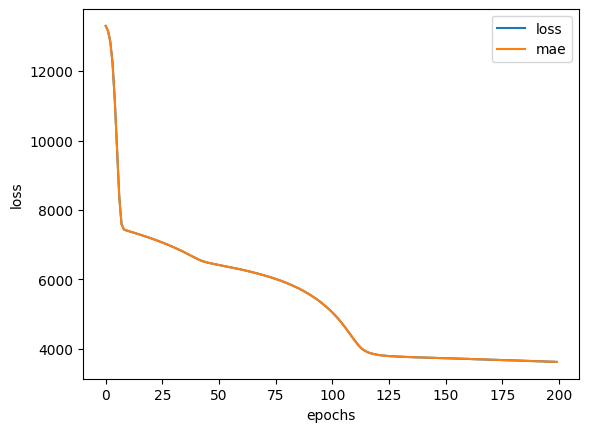

In [132]:
# Plot history (also known as a loss curve or a training curve)
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")

> **Question:** How long should you train for?

It depends. Really... it depends on the problem you're working on. However, many people have asked this question before... so TensorFlow has a solution! It's called the [EarlyStopping Callback](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping), which is a TensorFlow component you can add to your model to stop training once it stops improving a certain metric.

## Preprocessing data (normalization and standarization)

In terms of scaling values, neural networks tend to prefer normalization.

If you're not sure on which to use, you could try both and see which performs better.

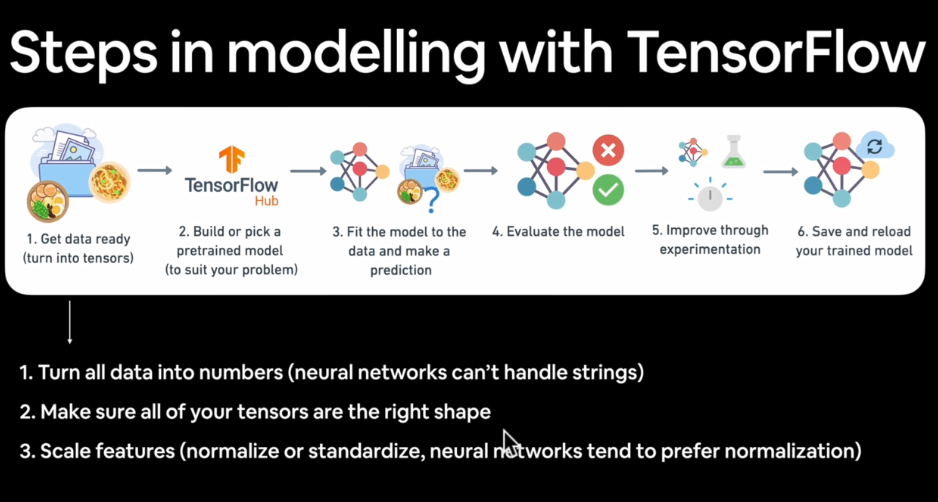

Here’s the precise distinction between **normalization** and **standardization** for your documentation:

| Aspect                 | Normalization (Min-Max Scaling)                                                            | Standardization (Z-score Scaling)                                                                                                                               |
| ---------------------- | ------------------------------------------------------------------------------------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Formula                | ( X' = \frac{X - X_{\min}}{X_{\max} - X_{\min}} )                                          | ( X' = \frac{X - \mu}{\sigma} )                                                                                                                                 |
| Output Range           | Usually [0, 1]                                                                             | Mean = 0, Std = 1 (range not fixed)                                                                                                                             |
| Sensitivity            | Sensitive to outliers                                                                      | Less sensitive to outliers                                                                                                                                      |
| Use Case               | When you want all features in same bounded scale (e.g., neural networks with sigmoid/tanh) | When data distribution is unknown or not bounded; works well with algorithms assuming Gaussian distribution (e.g., linear regression, logistic regression, SVM) |
| Effect on Distribution | Does not change the shape of distribution                                                  | Centers and scales distribution, can normalize variance                                                                                                         |

**Key point for neural networks:**

* Normalization is often used when the input features are bounded or when activations like sigmoid/tanh are used.
* Standardization is generally safer if features have different distributions or outliers, especially for deep networks with ReLU activations.

For your insurance dataset (age, bmi, children, etc.), **standardization** usually works better because you have numeric features with different scales and potential outliers.

If you want, I can tell you exactly **how to apply it to X and y** for your regression model to improve MAE.


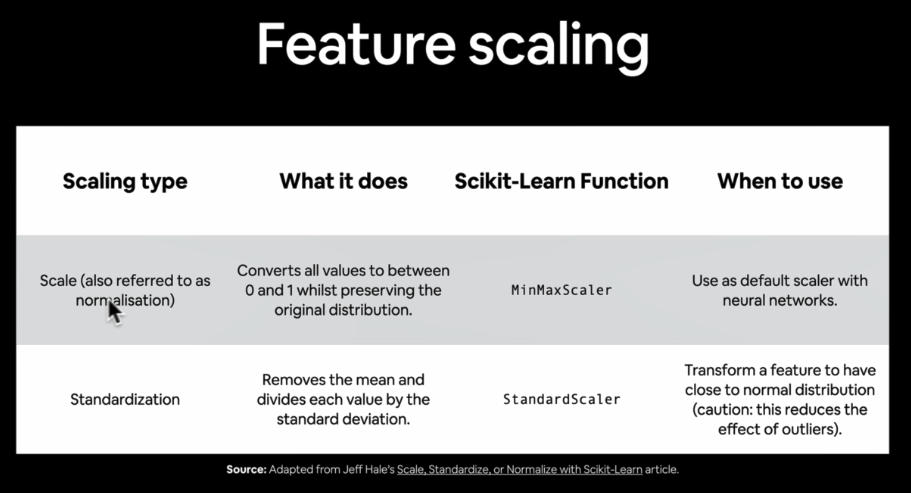

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Read in the insurance dataframe
insurance = pd.read_csv(EXTERNAL_URL)
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<h1 style="color:red">lec 027:-Preprocessing data with feature scaling part 2 (normalising our data).mp4</h1>

### To prepare our data, we can borrow a few classes from Scikit-Learn.

In [139]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Create a Column transformer
ct = make_column_transformer(
    (MinMaxScaler(),["age","bmi","children"]), # turn all values in these column between 0 and 1
    (OneHotEncoder(handle_unknown="ignore"),["sex","smoker","region"])
)

# Create X & y
X= insurance.drop("charges",axis=1)
y = insurance["charges"]

# Build our train and test sets
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Fit the column transformer to our training data
ct.fit(X_train)

# Transform training and test data with normalization (MinMaxScaler) and OneHotEncoder
# we broke them into X_train, X_test beacuse don't want to influence evaluation result by test participation
X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)


In [141]:
# What does our data look like now?
X_train_normal[0]

array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        ])

In [142]:
X_train.shape,X_train_normal.shape

((1070, 6), (1070, 11))

<h1 style="color:red">lec 028:-Preprocessing data with feature scaling part 3 (fitting a model on scaled data).mp4</h1>

Beautiful! Our data has been normalized and one hot encoded. Now let's build a neural network model on it and see how it goes.

In [144]:
# Build a neural network model to fit on our normalized data
tf.random.set_seed(42)

# 1. Create the model
insurance_model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100,activation="relu"),
    tf.keras.layers.Dense(10,activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model_4.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["mae"]
)

# 3. Fit the model
insurance_model_4.fit(X_train_normal,y_train,epochs=200,verbose=1)


Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 13298.4082 - mae: 13298.4082
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13296.7891 - mae: 13296.7891
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13292.3770 - mae: 13292.3770
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13282.0850 - mae: 13282.0850
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13262.7461 - mae: 13262.7461
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13230.7871 - mae: 13230.7871
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13182.5449 - mae: 13182.5449
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13114.2822 - mae: 13114.2822
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13021.9971 - mae: 13021.9971
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12902.6758 - mae: 12902.6758
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12753.0918 - mae: 12753.0918
Epoch 12/200
34/34 ━━━━━━━━━━━

In [145]:
# Evaluate our insurance model trained on normalized data
insurance_model_4.evaluate(X_test_normal,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3046.8987 - mae: 3046.8987  


[2942.270751953125, 2942.270751953125]

from IPython.core.display import display, HTML

html_content = """
<html>
<head>
<link href="https://maxcdn.bootstrapcdn.com/bootstrap/3.3.7/css/bootstrap.min.css" rel="stylesheet"
      integrity="sha384-BVYiiSIFeK1dGmJRAkycuHAHRg32OmUcww7on3RYdg4Va+PmSTsz/K68vbdEjh4u"
      crossorigin="anonymous">
<title>029 TensorFlow Regression challenge, exercises & extra-curriculum</title>
</head>
<body>
<div class="container">
<div class="row">
<div class="col-md-10 col-md-offset-1">
    <p class="lead"><p>Ho, ho, look at you go! You’ve already built your first neural networks with TensorFlow!</p>
    <p>Massive effort making it through neural network regression with TensorFlow.</p>
    <p>By now you should be able to describe what a regression problem is and put together different TensorFlow modules to be able to build a model which attempts to solve that problem.</p>
    <p>It’s that time again, time to put your new skills to work.</p>
    <p>In the <a href="https://github.com/mrdbourke/tensorflow-deep-learning" rel="noopener noreferrer" target="_blank">course GitHub repo</a> under “Course materials”, you'll find a series of exercises and extra-curriculum suggestions.</p>
    <p>By going through these, you'll get more hands-on practice building neural networks and start to understand what goes on behind the scenes.</p>
    <p>See the link below for more.</p>
    <ul>
        <li><p><a href="https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/README.md#-01-neural-network-regression-with-tensorflow-exercises" rel="noopener noreferrer" target="_blank">Neural Network Regression with TensorFlow Exercises &amp; Extra-curriculum</a></p></li>
    </ul>
    <p>And remember, if you have any questions, be sure to <a href="https://github.com/mrdbourke/tensorflow-deep-learning/discussions" rel="noopener noreferrer" target="_blank">add them to the discussions page</a>.</p>
    <p><strong>Challenge:</strong> Think of a regression problem you’ve come into contact with before, what it is? If you were going to build a neural network to solve it, what would the inputs be? What would the ideal outputs be?</p>
    <p>Send a message with your answer(s) to the #machinelearning-datascience channel on Discord and mention my name (@mrdbourke), I’d love to hear them!</p>
    <p>See you in the next module!</p>
    <p>- Daniel</p>
    <p>Web: <a href="http://www.mrdbourke.com/" rel="noopener noreferrer" target="_blank">www.mrdbourke.com</a></p>
    <p>YouTube: <a href="https://dbourke.link/youtube" rel="noopener noreferrer" target="_blank">https://dbourke.link/youtube</a></p>
</div>
</div>
</div>
<script src="https://maxcdn.bootstrapcdn.com/bootstrap/3.3.7/js/bootstrap.min.js"
        integrity="sha384-Tc5IQib027qvyjSMfHjOMaLkfuWVxZxUPnCJA7l2mCWNIpG9mGCD8wGNIcPD7Txa"
        crossorigin="anonymous"></script>
</body>
</html>
"""

display(HTML(html_content))


037 All-course-materials-and-links-notebooks-code-data-slides-on-GitHub
https://github.com/mrdbourke/tensorflow-deep-learning
